# Portfolio Selection: Markowitz (1952)

Each week in this course, we replicate the central result of a well-known
finance paper. We start with the paper that started modern portfolio theory:

> Markowitz, Harry. "Portfolio Selection." *The Journal of Finance* 7, no. 1
> (1952): 77-91.

Markowitz's idea fits in one sentence: an investor should care about the mean
and the variance of the return on the *whole portfolio*, not about each asset
one at a time. The expected return of a portfolio is a weighted average of the
expected returns of its assets. The risk of a portfolio is not. That gap is
diversification, and this notebook measures it with real data.

The data are monthly returns from CRSP, the Center for Research in Security
Prices, which we access through Wharton Research Data Services (WRDS). The
file `pull_crsp.py` in this repository contains the exact queries that
produced the extract we load below.

In [1]:
import inspect

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import mean_variance
import pull_crsp

## The data

Twelve large US stocks, monthly total returns (dividends included), 2000
through 2024. `MKT` is the CRSP value-weighted market return and `RF` is the
one-month Treasury bill rate.

In [2]:
df = pull_crsp.load_extract()
df.tail()

,AAPL,MSFT,AMZN,NVDA,JPM,XOM,JNJ,PG,KO,WMT,CAT,BA,MKT,RF
date,,,,,,,,,,,,,,
2024-08-31,0.032345,-0.001116,-0.045352,0.020082,0.056391,0.002476,0.058740,0.067057,0.085856,0.128324,0.028596,-0.088458,0.022022,0.0048
2024-09-30,0.017467,0.031548,0.043866,0.017426,-0.062011,-0.006105,-0.022911,0.009677,-0.001683,0.045578,0.098343,-0.124899,0.021040,0.0040
2024-10-31,-0.030429,-0.055659,0.000376,0.093215,0.058680,-0.003754,-0.013575,-0.040701,-0.091150,0.014861,-0.034674,-0.017956,-0.007766,0.0039
2024-11-30,0.051708,0.044202,0.115290,0.041353,0.125270,0.018399,-0.022558,0.085240,-0.011407,0.128737,0.079506,0.041056,0.066560,0.0040
2024-12-31,0.055155,-0.004629,0.055318,-0.028577,-0.040085,-0.088081,-0.067028,-0.064766,-0.028402,-0.021093,-0.106744,0.138703,-0.031325,0.0037


In [3]:
stocks = df.drop(columns=["MKT", "RF"])
rf = df["RF"].mean()

summary = pd.DataFrame(
    {
        "mean (annualized)": 12 * stocks.mean(),
        "volatility (annualized)": np.sqrt(12) * stocks.std(),
    }
)
summary["Sharpe ratio"] = (summary["mean (annualized)"] - 12 * rf) / summary[
    "volatility (annualized)"
]
summary.round(2)

,mean (annualized),volatility (annualized),Sharpe ratio
AAPL,0.31,0.38,0.77
MSFT,0.14,0.28,0.43
AMZN,0.26,0.44,0.55
NVDA,0.47,0.60,0.75
JPM,0.13,0.30,0.40
XOM,0.09,0.22,0.35
JNJ,0.08,0.16,0.41
PG,0.09,0.18,0.40
KO,0.07,0.17,0.32
WMT,0.09,0.19,0.38


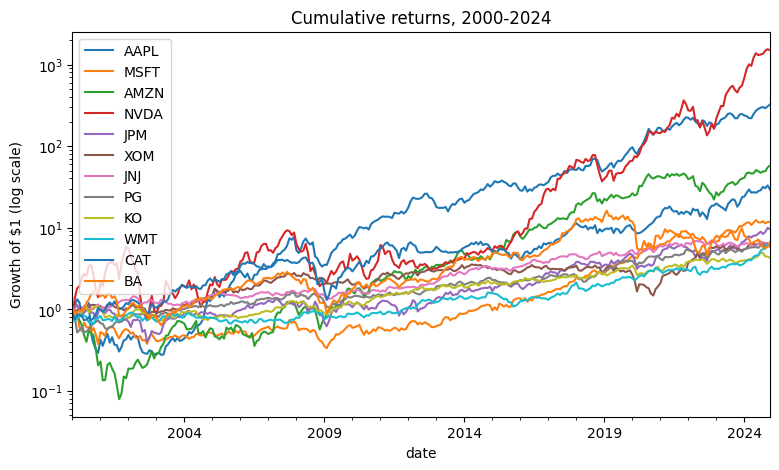

In [4]:
(1 + stocks).cumprod().plot(logy=True, figsize=(9, 5))
plt.ylabel("Growth of $1 (log scale)")
plt.title("Cumulative returns, 2000-2024");

## Two assets: the mean is linear in the weights, the risk is not

Put a fraction $w$ of your wealth in asset 1 and $1 - w$ in asset 2. Then

$$ E[R_p] = w \mu_1 + (1 - w) \mu_2 $$

$$ \text{Var}(R_p) = w^2 \sigma_1^2 + (1 - w)^2 \sigma_2^2
   + 2 w (1 - w) \rho \sigma_1 \sigma_2 $$

The expected return is a straight line in $w$. The variance is a parabola,
and the correlation $\rho$ controls how far it bends. Unless $\rho = 1$, some
mix of the two assets has less risk than the weighted average of their risks.

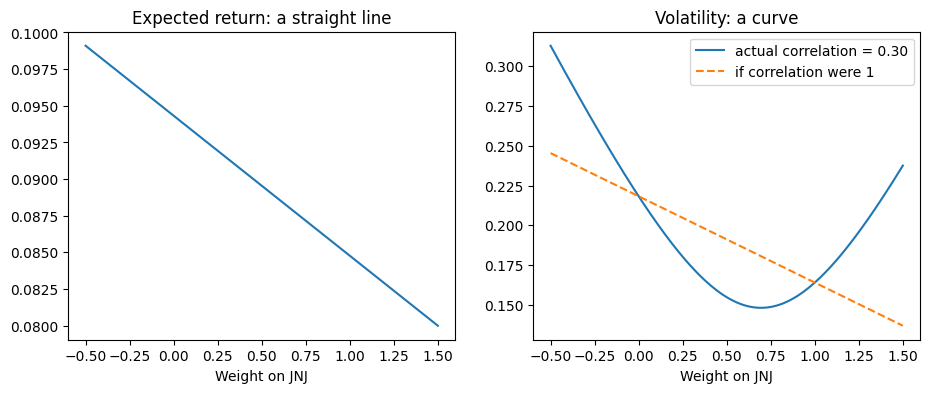

In [5]:
a, b = "JNJ", "XOM"
mu_a, mu_b = stocks[a].mean(), stocks[b].mean()
sd_a, sd_b = stocks[a].std(), stocks[b].std()
rho = stocks[a].corr(stocks[b])

w = np.linspace(-0.5, 1.5, 201)
mean_p = w * mu_a + (1 - w) * mu_b
sd_p = np.sqrt(
    w**2 * sd_a**2 + (1 - w) ** 2 * sd_b**2 + 2 * w * (1 - w) * rho * sd_a * sd_b
)
sd_if_perfectly_correlated = np.abs(w * sd_a + (1 - w) * sd_b)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(w, 12 * mean_p)
axes[0].set_title("Expected return: a straight line")
axes[0].set_xlabel(f"Weight on {a}")
axes[1].plot(w, np.sqrt(12) * sd_p, label=f"actual correlation = {rho:.2f}")
axes[1].plot(
    w,
    np.sqrt(12) * sd_if_perfectly_correlated,
    linestyle="--",
    label="if correlation were 1",
)
axes[1].set_title("Volatility: a curve")
axes[1].set_xlabel(f"Weight on {a}")
axes[1].legend();

## The mean-variance problem

With $N$ assets, collect the portfolio weights in a vector $w$, the expected
returns in $\mu$, and the covariances of returns in the matrix $\Sigma$. The
two formulas above become

$$ E[R_p] = w^\top \mu, \qquad \text{Var}(R_p) = w^\top \Sigma w. $$

Markowitz's problem is to find, for each target expected return $m$, the
portfolio with the smallest variance:

$$
\min_{w} \; \tfrac{1}{2} w^\top \Sigma w
\quad \text{subject to} \quad
w^\top \mu = m, \qquad w^\top \mathbf{1} = 1.
$$

The set of solutions, traced out as $m$ varies, is the **mean-variance
frontier**. Weights may be negative here: a negative weight is a short
position.

### The solution

This problem has a closed-form solution. Define the scalars

$$
A = \mathbf{1}^\top \Sigma^{-1} \mathbf{1}, \quad
B = \mathbf{1}^\top \Sigma^{-1} \mu, \quad
C = \mu^\top \Sigma^{-1} \mu, \quad
D = AC - B^2 .
$$

Then the optimal weights and the minimized variance are

$$
w^*(m) = \frac{(C - Bm)\, \Sigma^{-1} \mathbf{1} + (Am - B)\, \Sigma^{-1} \mu}{D},
\qquad
\sigma^2(m) = \frac{A m^2 - 2 B m + C}{D}.
$$

The variance is a parabola in $m$, so in the usual picture, with volatility
on the horizontal axis, the frontier is a hyperbola. Two portfolios on it
have names.

- The **global minimum variance portfolio** sits at the tip, where
  $m = B/A$ and $\sigma^2 = 1/A$:
  $$ w_{\text{GMV}} = \frac{\Sigma^{-1} \mathbf{1}}{\mathbf{1}^\top \Sigma^{-1} \mathbf{1}}. $$
  Notice that $\mu$ does not appear. That matters later.
- The **tangency portfolio** has the highest Sharpe ratio. Once investors can
  also hold a risk-free asset with return $r_f$, it is the only portfolio of
  risky assets that any of them wants:
  $$ w_{\text{tan}} = \frac{\Sigma^{-1} (\mu - r_f \mathbf{1})}
     {\mathbf{1}^\top \Sigma^{-1} (\mu - r_f \mathbf{1})}. $$

The derivation, which takes one Lagrangian and a page of algebra, is in the
appendix notebook, `02_markowitz_derivation.ipynb.py`.

### In code

We estimate $\mu$ and $\Sigma$ with the sample mean and sample covariance.

In [6]:
mu = stocks.mean().values
Sigma = stocks.cov().values
ones = np.ones(len(mu))

w_gmv = np.linalg.solve(Sigma, ones)
w_gmv = w_gmv / w_gmv.sum()

w_tan = np.linalg.solve(Sigma, mu - rf)
w_tan = w_tan / w_tan.sum()

pd.DataFrame({"GMV": w_gmv, "Tangency": w_tan}, index=stocks.columns).round(3)

,GMV,Tangency
AAPL,0.047,0.242
MSFT,0.055,-0.106
AMZN,0.003,0.040
NVDA,0.001,0.143
JPM,0.015,-0.041
XOM,0.162,0.021
JNJ,0.187,0.136
PG,0.242,0.304
KO,0.121,0.012
WMT,0.221,0.146


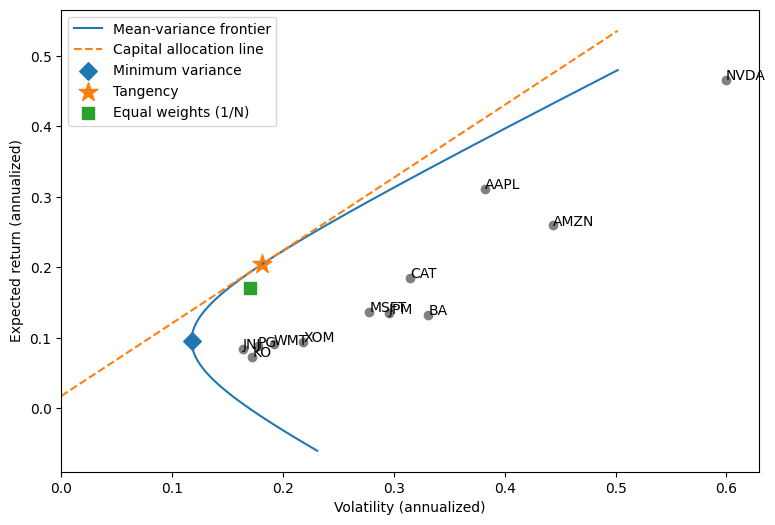

In [7]:
targets = np.linspace(-0.005, 0.04, 200)  # monthly target means
frontier_vol = np.sqrt(mean_variance.frontier_variance(mu, Sigma, targets))


def annualized_mean_and_vol(weights):
    return 12 * weights @ mu, np.sqrt(12 * weights @ Sigma @ weights)


mean_gmv, vol_gmv = annualized_mean_and_vol(w_gmv)
mean_tan, vol_tan = annualized_mean_and_vol(w_tan)
mean_ew, vol_ew = annualized_mean_and_vol(ones / len(ones))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(np.sqrt(12) * frontier_vol, 12 * targets, label="Mean-variance frontier")
vol_grid = np.linspace(0, np.sqrt(12) * frontier_vol.max(), 50)
ax.plot(
    vol_grid,
    12 * rf + (mean_tan - 12 * rf) / vol_tan * vol_grid,
    linestyle="--",
    label="Capital allocation line",
)
ax.scatter(summary["volatility (annualized)"], summary["mean (annualized)"], color="gray")
for ticker, row in summary.iterrows():
    ax.annotate(ticker, (row["volatility (annualized)"], row["mean (annualized)"]))
ax.scatter(vol_gmv, mean_gmv, marker="D", s=80, label="Minimum variance")
ax.scatter(vol_tan, mean_tan, marker="*", s=200, label="Tangency")
ax.scatter(vol_ew, mean_ew, marker="s", s=80, label="Equal weights (1/N)")
ax.set_xlabel("Volatility (annualized)")
ax.set_ylabel("Expected return (annualized)")
ax.set_xlim(left=0)
ax.legend();

## No short sales: when the closed form runs out

Look again at the weights above. Several are negative. Many investors cannot
short, or cannot short cheaply, so the more realistic problem adds one more
constraint:

$$
\min_{w} \; \tfrac{1}{2} w^\top \Sigma w
\quad \text{subject to} \quad
w^\top \mu = m, \qquad w^\top \mathbf{1} = 1, \qquad w \ge 0 .
$$

This version has **no closed-form solution**. The reason is the inequality.
At the optimum, some assets are held in positive amounts and the rest sit
exactly at zero. If we knew in advance which assets were in which group, we
could drop the zero-weight assets and apply the formula above to the rest.
But we do not know, and the grouping changes as the target $m$ changes. The
frontier is stitched together from segments, one for each grouping, joined at
"corner portfolios" where an asset enters or leaves. Markowitz (1956) worked
out an algorithm to find those corners, the critical line algorithm. There is
an algorithm, but no formula.

In practice we hand the problem to a numerical optimizer. It is a quadratic
program (a quadratic objective with linear constraints), which is about the
friendliest kind of optimization problem there is. Here is the function in
`mean_variance.py` that solves it:

In [8]:
print(inspect.getsource(mean_variance.minimize_variance))

def minimize_variance(mu, Sigma, target=None, allow_short=True):
    """Numerically solve for the minimum variance weights.

    If `target` is None, there is no constraint on the mean, which gives the
    global minimum variance portfolio. If `allow_short` is False, every weight
    is constrained to be nonnegative.
    """
    n = len(mu)
    scale = 1 / np.mean(np.diag(Sigma))  # keeps the objective near 1 for the solver

    constraints = [{"type": "eq", "fun": lambda w: w.sum() - 1}]
    x0 = np.ones(n) / n
    if target is not None:
        spread = mu.max() - mu.min()
        constraints.append({"type": "eq", "fun": lambda w: (w @ mu - target) / spread})
        # Start from a portfolio that already hits the target: a mix of the
        # lowest-mean and highest-mean assets.
        share = (target - mu.min()) / spread
        x0 = np.zeros(n)
        x0[mu.argmin()] += 1 - share
        x0[mu.argmax()] += share

    result = minimize(
        fun=lambda w: scale * w @ Sigma @ w

A constraint can never improve an optimum, so the no-short frontier must lie
inside the unconstrained one. It also has endpoints: without shorting or
leverage, no portfolio can have a higher expected return than the single best
asset, or a lower one than the single worst.

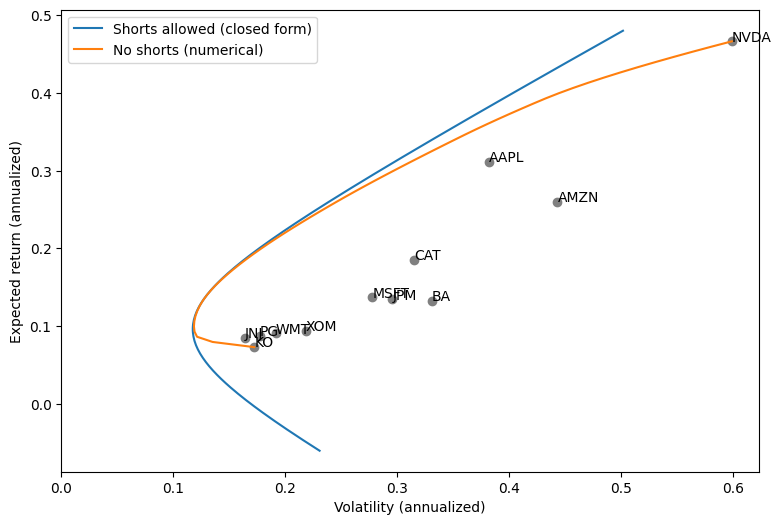

In [9]:
targets_no_short = np.linspace(mu.min(), mu.max(), 60)
weights_no_short = mean_variance.frontier(mu, Sigma, targets_no_short, allow_short=False)
vol_no_short = np.sqrt([w @ Sigma @ w for w in weights_no_short])

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(np.sqrt(12) * frontier_vol, 12 * targets, label="Shorts allowed (closed form)")
ax.plot(np.sqrt(12) * vol_no_short, 12 * targets_no_short, label="No shorts (numerical)")
ax.scatter(summary["volatility (annualized)"], summary["mean (annualized)"], color="gray")
for ticker, row in summary.iterrows():
    ax.annotate(ticker, (row["volatility (annualized)"], row["mean (annualized)"]))
ax.set_xlabel("Volatility (annualized)")
ax.set_ylabel("Expected return (annualized)")
ax.set_xlim(left=0)
ax.legend();

The composition of the no-short frontier shows the segments directly. Moving
up the frontier toward higher expected returns, assets drop out one at a time
until only the highest-mean stock is left.

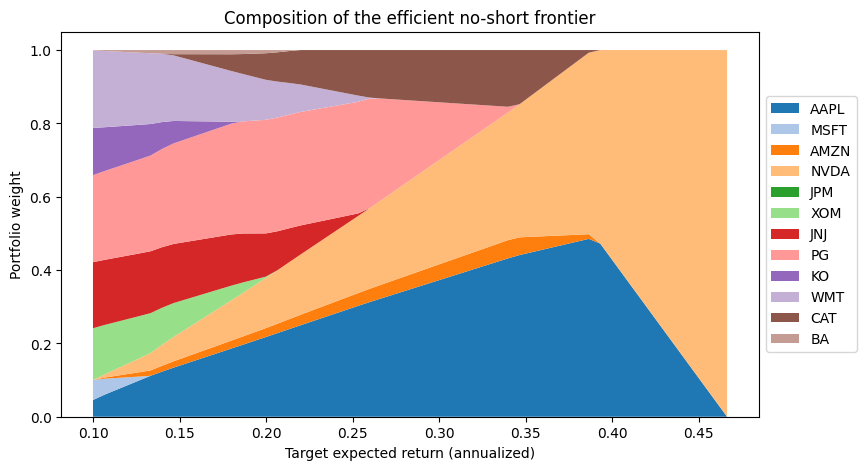

In [10]:
efficient = targets_no_short >= weights_no_short[np.argmin(vol_no_short)] @ mu

fig, ax = plt.subplots(figsize=(9, 5))
ax.stackplot(
    12 * targets_no_short[efficient],
    weights_no_short[efficient].T,
    labels=stocks.columns,
    colors=plt.cm.tab20.colors,  # twelve assets need more than the default ten colors
)
ax.set_xlabel("Target expected return (annualized)")
ax.set_ylabel("Portfolio weight")
ax.set_title("Composition of the efficient no-short frontier")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5));

## The catch: the optimizer maximizes your estimation error

Everything above treated $\mu$ and $\Sigma$ as known. They are estimates, and
expected returns in particular are estimated very imprecisely. The optimizer
does not know that. It leans hardest on whichever assets *look* best in the
sample, which are disproportionately the ones whose means were overestimated.
Michaud (1989) called mean-variance optimization an "error maximizer."

To see it, estimate the tangency portfolio on the first half of the sample and
again on the second half.

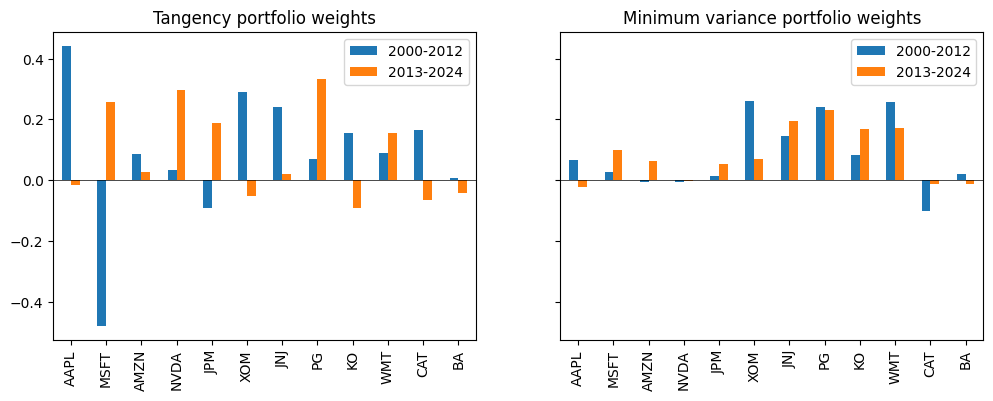

In [11]:
def tangency_weights(returns, rf):
    w = np.linalg.solve(returns.cov().values, returns.mean().values - rf)
    return pd.Series(w / w.sum(), index=returns.columns)


def gmv_weights(returns):
    w = np.linalg.solve(returns.cov().values, np.ones(returns.shape[1]))
    return pd.Series(w / w.sum(), index=returns.columns)


first, second = stocks.loc[:"2012"], stocks.loc["2013":]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
pd.DataFrame(
    {"2000-2012": tangency_weights(first, rf), "2013-2024": tangency_weights(second, rf)}
).plot.bar(ax=axes[0], title="Tangency portfolio weights")
pd.DataFrame(
    {"2000-2012": gmv_weights(first), "2013-2024": gmv_weights(second)}
).plot.bar(ax=axes[1], title="Minimum variance portfolio weights")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[1].axhline(0, color="black", linewidth=0.5);

The tangency weights change sign from one half of the sample to the other.
The minimum variance weights, which do not depend on $\mu$, are far more
stable. This is one reason that a naive equal-weighted portfolio is so hard to
beat out of sample (DeMiguel, Garlappi, and Uppal, 2009). It is also one
reason practitioners impose constraints like the no-short constraint even
when they *can* short: a constraint limits how far the optimizer can chase
estimation error.

It is also the first argument for the subject of this course. If a small
change in the inputs can flip the answer, then a result is only as credible as
your ability to say exactly which data, which code, and which software
versions produced it, and to produce it again on demand. That is what a
**reproducible analytical pipeline** gives you.

## Your turn

The minimum variance and tangency calculations above work, but they live in a
notebook: nothing checks them, and nothing else can import them. In HW 0 you
will move them into `port_opt.py`, where a set of unit tests verifies them
automatically every time you push to GitHub.

## References

- DeMiguel, Victor, Lorenzo Garlappi, and Raman Uppal. "Optimal Versus Naive
  Diversification: How Inefficient Is the 1/N Portfolio Strategy?" *The Review
  of Financial Studies* 22, no. 5 (2009): 1915-1953.
- Markowitz, Harry. "Portfolio Selection." *The Journal of Finance* 7, no. 1
  (1952): 77-91.
- Markowitz, Harry. "The Optimization of a Quadratic Function Subject to
  Linear Constraints." *Naval Research Logistics Quarterly* 3, no. 1-2 (1956):
  111-133.
- Merton, Robert C. "An Analytic Derivation of the Efficient Portfolio
  Frontier." *Journal of Financial and Quantitative Analysis* 7, no. 4 (1972):
  1851-1872.
- Michaud, Richard O. "The Markowitz Optimization Enigma: Is 'Optimized'
  Optimal?" *Financial Analysts Journal* 45, no. 1 (1989): 31-42.